Shape: (1338, 7)
Duplicates removed. New shape: (1337, 7)


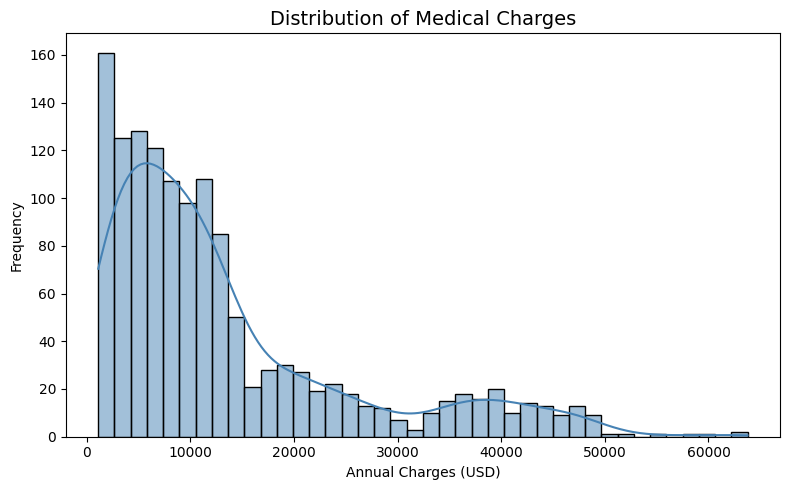

Saved: graph_1_charges_distribution.png


/tmp/ipykernel_5002/741682611.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')


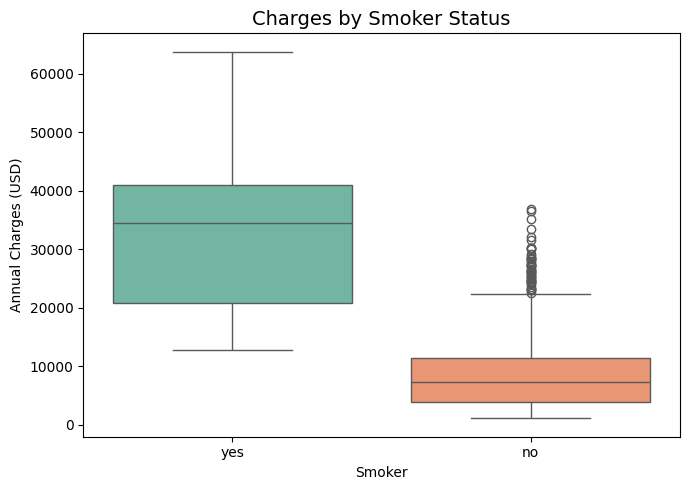

Saved: graph_2_boxplot_smoker.png


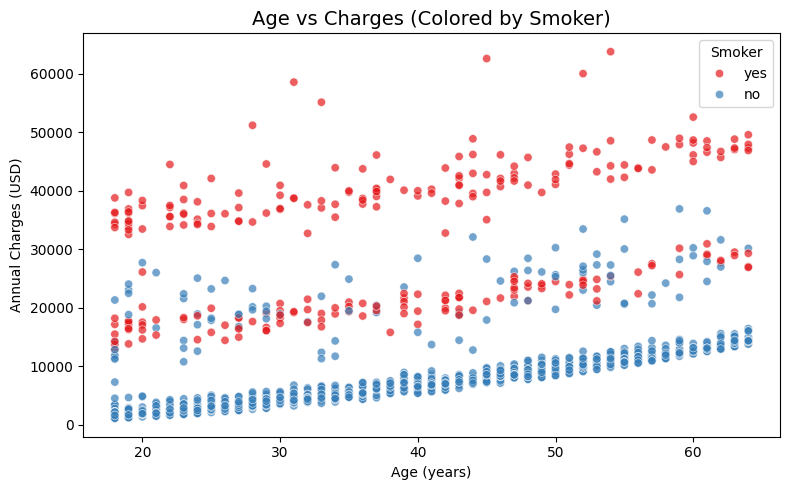

Saved: graph_3_age_vs_charges_smoker.png


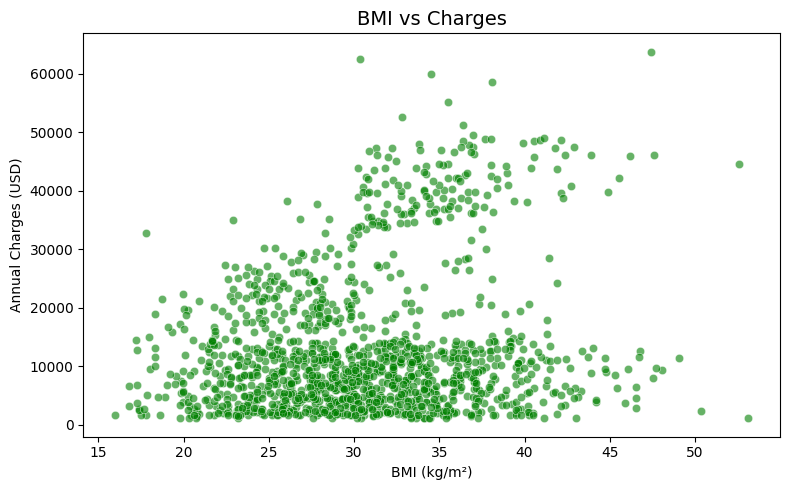

Saved: graph_4_bmi_vs_charges.png


/tmp/ipykernel_5002/741682611.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='region', y='charges', ax=ax1, palette='pastel')
/tmp/ipykernel_5002/741682611.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='charges', ax=ax2, palette='pastel')


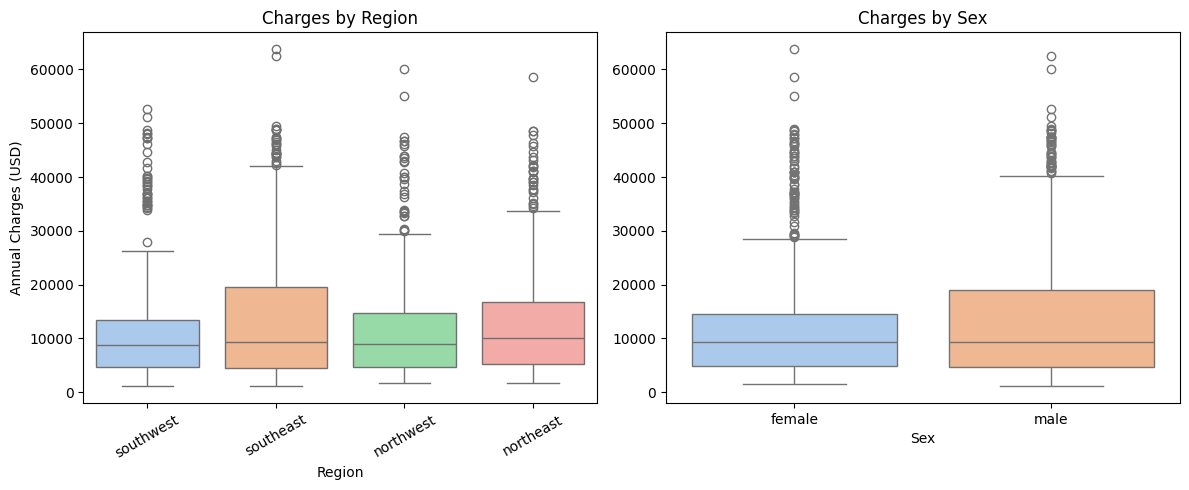

Saved: graph_5_region_and_sex_boxplots.png


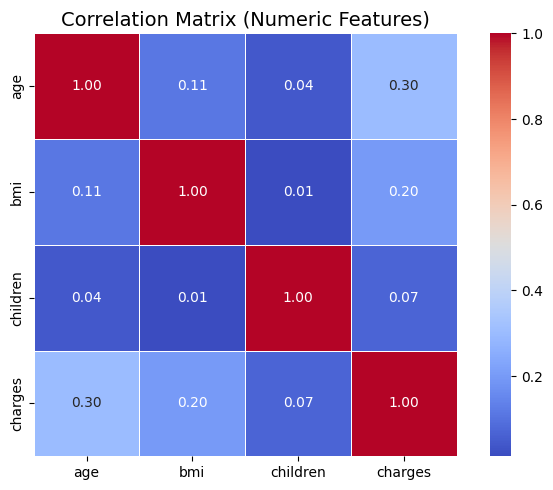

Saved: graph_6_correlation_matrix.png


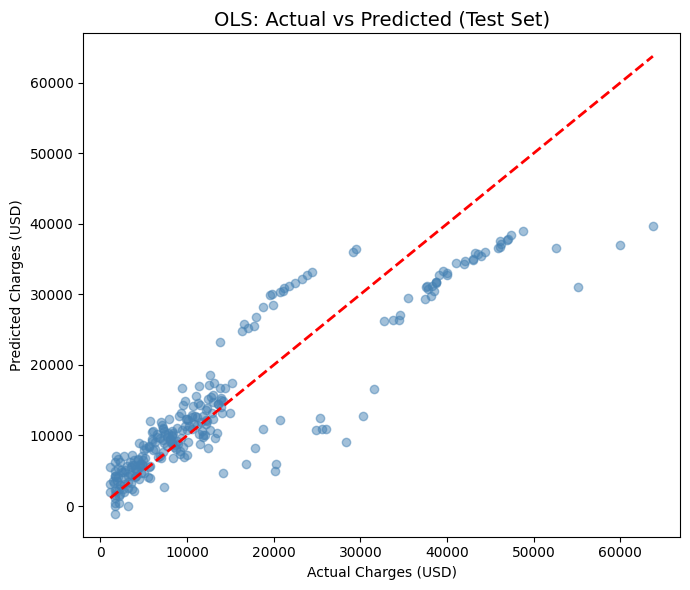

Saved: graph_7_actual_vs_predicted.png
Saved scaler.pkl and ols_model.pkl

--- Model Performance (Test Set) ---
OLS -> R² = 0.807, MAE = $4177, RMSE = $5956

Top positive drivers:
      Feature   Coefficient
4  smoker_yes  23077.764593
0         age   3472.975553
1         bmi   1927.828251

Top negative drivers:
            Feature  Coefficient
5  region_northwest  -391.761455
7  region_southwest  -659.139752
6  region_southeast  -838.919616


In [2]:
# -*- coding: utf-8 -*-
"""Generate all graphs for final project presentation"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# ------------------------------------------------------------
# 1. Load and clean data
# ------------------------------------------------------------
df = pd.read_csv('insurance.csv')
print("Shape:", df.shape)
df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)

# ------------------------------------------------------------
# 2. Graph 1 – Distribution of charges (histogram + KDE)
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Medical Charges', fontsize=14)
plt.xlabel('Annual Charges (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('graph_1_charges_distribution.png', dpi=150)
plt.show()
print("Saved: graph_1_charges_distribution.png")

# ------------------------------------------------------------
# 3. Graph 2 – Boxplot: charges by smoker
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')
plt.title('Charges by Smoker Status', fontsize=14)
plt.xlabel('Smoker')
plt.ylabel('Annual Charges (USD)')
plt.tight_layout()
plt.savefig('graph_2_boxplot_smoker.png', dpi=150)
plt.show()
print("Saved: graph_2_boxplot_smoker.png")

# ------------------------------------------------------------
# 4. Graph 3 – Scatter plot: age vs charges (colored by smoker)
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7, palette='Set1')
plt.title('Age vs Charges (Colored by Smoker)', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Annual Charges (USD)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.savefig('graph_3_age_vs_charges_smoker.png', dpi=150)
plt.show()
print("Saved: graph_3_age_vs_charges_smoker.png")

# ------------------------------------------------------------
# 5. Graph 4 – Scatter plot: bmi vs charges
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='bmi', y='charges', alpha=0.6, color='green')
plt.title('BMI vs Charges', fontsize=14)
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Annual Charges (USD)')
plt.tight_layout()
plt.savefig('graph_4_bmi_vs_charges.png', dpi=150)
plt.show()
print("Saved: graph_4_bmi_vs_charges.png")

# ------------------------------------------------------------
# 6. Graph 5 – Boxplots: charges by region and by sex (two in one figure)
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Charges by region
sns.boxplot(data=df, x='region', y='charges', ax=ax1, palette='pastel')
ax1.set_title('Charges by Region', fontsize=12)
ax1.set_xlabel('Region')
ax1.set_ylabel('Annual Charges (USD)')
ax1.tick_params(axis='x', rotation=30)

# Charges by sex
sns.boxplot(data=df, x='sex', y='charges', ax=ax2, palette='pastel')
ax2.set_title('Charges by Sex', fontsize=12)
ax2.set_xlabel('Sex')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('graph_5_region_and_sex_boxplots.png', dpi=150)
plt.show()
print("Saved: graph_5_region_and_sex_boxplots.png")

# ------------------------------------------------------------
# 7. Graph 6 – Correlation matrix heatmap (numeric columns)
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
numeric_cols = ['age', 'bmi', 'children', 'charges']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)', fontsize=14)
plt.tight_layout()
plt.savefig('graph_6_correlation_matrix.png', dpi=150)
plt.show()
print("Saved: graph_6_correlation_matrix.png")

# ------------------------------------------------------------
# 8. Graph 7 – Actual vs Predicted (OLS) scatter plot
# ------------------------------------------------------------
# We need to run a quick model to get predictions
X = pd.get_dummies(df.drop('charges', axis=1), columns=['sex', 'smoker', 'region'], drop_first=True)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
num_features = ['age', 'bmi', 'children']
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred = ols.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.title('OLS: Actual vs Predicted (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig('graph_7_actual_vs_predicted.png', dpi=150)
plt.show()
print("Saved: graph_7_actual_vs_predicted.png")

# ------------------------------------------------------------
# 9. Save model and scaler (for Streamlit dashboard)
# ------------------------------------------------------------
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(ols, 'ols_model.pkl')
print("Saved scaler.pkl and ols_model.pkl")

# ------------------------------------------------------------
# 10. Print final evaluation (for your reference)
# ------------------------------------------------------------
print("\n--- Model Performance (Test Set) ---")
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"OLS -> R² = {r2:.3f}, MAE = ${mae:.0f}, RMSE = ${rmse:.0f}")

# Top coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': ols.coef_}).sort_values('Coefficient', ascending=False)
print("\nTop positive drivers:")
print(coef_df.head(3))
print("\nTop negative drivers:")
print(coef_df.tail(3))